In [1]:
!pip install pandas scikit-learn

  Using cached tzdata-2025.3-py2.py3-none-any.whl.metadata (1.4 kB)
   ---------------------------------------- 0.0/9.7 MB ? eta -:--:--
   ---------------------------------------- 9.7/9.7 MB 72.6 MB/s  0:00:00
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------------------------------------- 8.0/8.0 MB 84.0 MB/s  0:00:00
   ---------------------------------------- 0.0/36.5 MB ? eta -:--:--
   ------------------------ --------------- 22.5/36.5 MB 113.0 MB/s eta 0:00:01
   ---------------------------------------- 36.5/36.5 MB 98.4 MB/s  0:00:00
Using cached tzdata-2025.3-py2.py3-none-any.whl (348 kB)

   ---------------------------------------- 0/6 [tzdata]
   ------------- -------------------------- 2/6 [scipy]
   ------------- -------------------------- 2/6 [scipy]
   ------------- -------------------------- 2/6 [scipy]
   ------------- -------------------------- 2/6 [scipy]
   ------------- -------------------------- 2/6 [scipy]
   ------------- --------

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from mpl_toolkits.mplot3d import Axes3D

In [3]:
print( "DATA ENGINEERING STAGE")

np.random.seed(42)

# Simulate raw IoT sensor stream
timestamps = pd.date_range("2026-01-01", periods=300, freq="min")

raw_data = pd.DataFrame({
    "timestamp": timestamps,
    "lux": np.random.normal(300, 50, 300),
    "motion": np.random.choice([0, 1], 300)
})

# Introduce missing values (realistic scenario)
raw_data.loc[10:20, "lux"] = np.nan

print("\nRaw Data Sample:")
display(raw_data.head())
display(raw_data.iloc[5:16])

# ---- Cleaning ----

# Fill missing lux values
raw_data["lux"] = raw_data["lux"].ffill()

# Remove invalid readings
raw_data = raw_data[(raw_data["lux"] > 0)]

print("\nCleaned Data Sample:")
display(raw_data.head())
display(raw_data.iloc[5:16])

DATA ENGINEERING STAGE

Raw Data Sample:


,timestamp,lux,motion
0,2026-01-01 00:00:00,324.835708,0
1,2026-01-01 00:01:00,293.086785,1
2,2026-01-01 00:02:00,332.384427,1
3,2026-01-01 00:03:00,376.151493,0
4,2026-01-01 00:04:00,288.292331,0


,timestamp,lux,motion
5,2026-01-01 00:05:00,288.293152,1
6,2026-01-01 00:06:00,378.960641,1
7,2026-01-01 00:07:00,338.371736,0
8,2026-01-01 00:08:00,276.526281,0
9,2026-01-01 00:09:00,327.128002,0
10,2026-01-01 00:10:00,NaN,1
11,2026-01-01 00:11:00,NaN,1
12,2026-01-01 00:12:00,NaN,1
13,2026-01-01 00:13:00,NaN,0
14,2026-01-01 00:14:00,NaN,0



Cleaned Data Sample:


,timestamp,lux,motion
0,2026-01-01 00:00:00,324.835708,0
1,2026-01-01 00:01:00,293.086785,1
2,2026-01-01 00:02:00,332.384427,1
3,2026-01-01 00:03:00,376.151493,0
4,2026-01-01 00:04:00,288.292331,0


,timestamp,lux,motion
5,2026-01-01 00:05:00,288.293152,1
6,2026-01-01 00:06:00,378.960641,1
7,2026-01-01 00:07:00,338.371736,0
8,2026-01-01 00:08:00,276.526281,0
9,2026-01-01 00:09:00,327.128002,0
10,2026-01-01 00:10:00,327.128002,1
11,2026-01-01 00:11:00,327.128002,1
12,2026-01-01 00:12:00,327.128002,1
13,2026-01-01 00:13:00,327.128002,0
14,2026-01-01 00:14:00,327.128002,0



===== FEATURE ENGINEERING STAGE =====


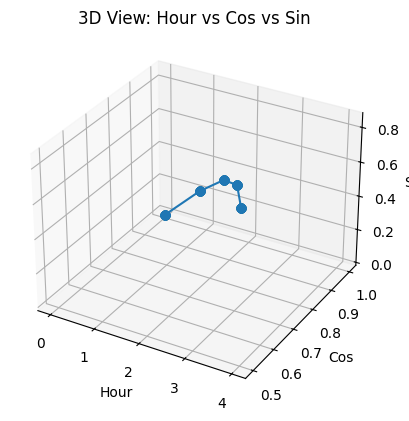


Feature Engineered Data Sample:


,timestamp,lux,motion,lux_rolling_mean,lux_comfort_diff,hour,hour_sin,hour_cos,occupied_lux
4,2026-01-01 00:04:00,288.292331,0,322.950149,-61.707669,0,0.0,1.0,0.000000
5,2026-01-01 00:05:00,288.293152,1,315.641638,-61.706848,0,0.0,1.0,288.293152
6,2026-01-01 00:06:00,378.960641,1,332.816409,28.960641,0,0.0,1.0,378.960641
7,2026-01-01 00:07:00,338.371736,0,334.013871,-11.628264,0,0.0,1.0,0.000000
8,2026-01-01 00:08:00,276.526281,0,314.088828,-73.473719,0,0.0,1.0,0.000000


In [4]:
# =========================================================
# 2️⃣ FEATURE ENGINEERING LAYER
# =========================================================
print("\n===== FEATURE ENGINEERING STAGE =====")

df = raw_data.copy()

# Rolling brightness average
df["lux_rolling_mean"] = df["lux"].rolling(window=5).mean()

# Deviation from comfort level (350 lux)
df["lux_comfort_diff"] = df["lux"] - 350

# Time encoding (cyclic)
df["hour"] = df["timestamp"].dt.hour
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

# 3D Plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot(df["hour"], df["hour_cos"], df["hour_sin"], marker='o')
ax.set_xlabel("Hour")
ax.set_ylabel("Cos")
ax.set_zlabel("Sin")
ax.set_title("3D View: Hour vs Cos vs Sin")

plt.show()

# Occupancy interaction
df["occupied_lux"] = df["lux"] * df["motion"]

# Drop NaNs caused by rolling
df = df.dropna()

print("\nFeature Engineered Data Sample:")
display(df.head())


===== VISUALIZATION =====


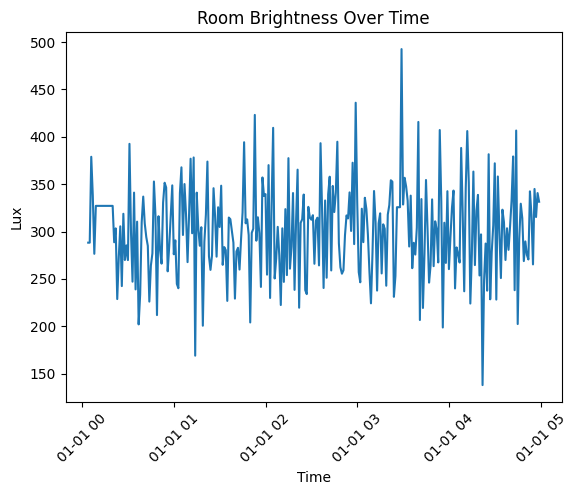

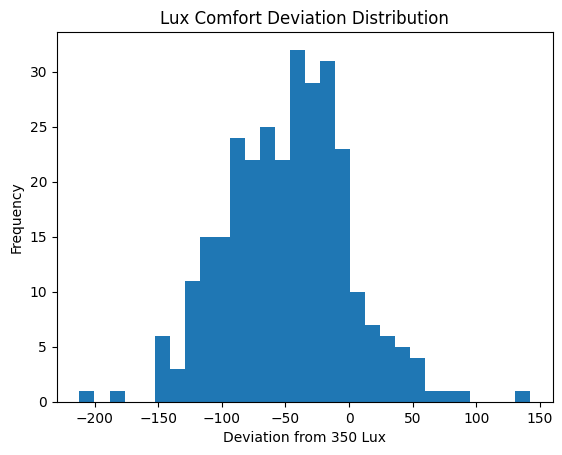

In [5]:
print("\n===== VISUALIZATION =====")

plt.figure()
plt.plot(df["timestamp"], df["lux"])
plt.title("Room Brightness Over Time")
plt.xlabel("Time")
plt.ylabel("Lux")
plt.xticks(rotation=45)
plt.show()

plt.figure()
plt.hist(df["lux_comfort_diff"], bins=30)
plt.title("Lux Comfort Deviation Distribution")
plt.xlabel("Deviation from 350 Lux")
plt.ylabel("Frequency")
plt.show()